# Imports:

In [1]:
import pandas as pd
import json
from torchvision import transforms
import uuid
import os
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from model_utils import *

In [2]:
# path for the new images
base_path = "./data" 
aug_dir = os.path.join(base_path, "HAM10000_augmented")
if not os.path.exists(aug_dir):
    os.makedirs(aug_dir)

In [3]:
# 1. Load the CSVs without 'dx_encoded' (since it's not in the file)
train_df = pd.read_csv('data/train_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path', 'dx']]
val_df = pd.read_csv('data/val_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path', 'dx']]
test_df = pd.read_csv('data/test_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path','dx']]

# 2. Load your mapping dictionary
with open("label2idx.json", "r") as f:
    label2idx = json.load(f)

# 3. Re-create the encoded column using the loaded dictionary
train_df["dx_encoded"] = train_df["dx"].map(label2idx)
val_df["dx_encoded"] = val_df["dx"].map(label2idx)
test_df["dx_encoded"] = test_df["dx"].map(label2idx)

In [5]:
train_df.head()

,image_id,dataset,lesion_id,cleaned_path,dx,dx_encoded
0,ISIC_0028291,vidir_modern,HAM_0006253,./data\HAM10000_cleaned\train\ISIC_0028291_cle...,mel,4
1,ISIC_0028308,rosendahl,HAM_0003752,./data\HAM10000_cleaned\train\ISIC_0028308_cle...,bkl,2
2,ISIC_0028286,vidir_molemax,HAM_0005470,./data\HAM10000_cleaned\train\ISIC_0028286_cle...,nv,5
3,ISIC_0028288,rosendahl,HAM_0004709,./data\HAM10000_cleaned\train\ISIC_0028288_cle...,mel,4
4,ISIC_0028313,vidir_molemax,HAM_0004166,./data\HAM10000_cleaned\train\ISIC_0028313_cle...,nv,5


In [6]:
train_df = train_df.rename(columns={'cleaned_path': 'image_path'})
val_df = val_df.rename(columns={'cleaned_path': 'image_path'})
test_df = test_df.rename(columns={'cleaned_path': 'image_path'})

train_df['dataset'] = 'original'
val_df['dataset'] = 'original'
test_df['dataset'] = 'original'

with open("label2idx.json", "r") as f:
    label2idx = json.load(f)

In [7]:
train_df.head()

,image_id,dataset,lesion_id,image_path,dx,dx_encoded
0,ISIC_0028291,original,HAM_0006253,./data\HAM10000_cleaned\train\ISIC_0028291_cle...,mel,4
1,ISIC_0028308,original,HAM_0003752,./data\HAM10000_cleaned\train\ISIC_0028308_cle...,bkl,2
2,ISIC_0028286,original,HAM_0005470,./data\HAM10000_cleaned\train\ISIC_0028286_cle...,nv,5
3,ISIC_0028288,original,HAM_0004709,./data\HAM10000_cleaned\train\ISIC_0028288_cle...,mel,4
4,ISIC_0028313,original,HAM_0004166,./data\HAM10000_cleaned\train\ISIC_0028313_cle...,nv,5


# Data Augmentation

## Strategies per Class

In [11]:
# ImageNet Transfer Learning RGB Weights
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

In [12]:
# PYTORCH?

# ── STRATEGY 1 — Light (geometric only) ──────────────────────────────────────
# Safe flips and rotation, nothing that touches color or structure
strategy_1 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Save version without ToTensor and Normalize
save_strategy_1 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
])

# ── STRATEGY 2 — Moderate (geometry + mild color) ─────────────────────────────
# Adds subtle brightness/contrast to simulate lighting variation
strategy_2 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.05)),  # simulates hair/occlusion
])

# Save version without ToTensor and Normalize
save_strategy_2 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

# ── STRATEGY 3 — Aggressive (everything + elastic + perspective) ────────────
# Most aggressive — use only for extreme minority classes (vasc, df)
strategy_3 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.15, hue=0.05),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ElasticTransform(alpha=40.0, sigma=4.0),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.35, scale=(0.02, 0.08)),
])

# Save version without ToTensor and Normalize
save_strategy_3 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.15, hue=0.05),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ElasticTransform(alpha=40.0, sigma=4.0),
])

# Base strategy, for the majority class
strat_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

save_strat_base = transforms.Compose([]) #no transformations for base when saving

In [13]:
strategy_map = {
    "nv":    strat_base,
    "mel":   strategy_1,
    "bkl":   strategy_1,
    "bcc":   strategy_2,
    "akiec": strategy_2,
    "vasc":  strategy_3,
    "df":    strategy_3,
}

save_strategy_map = {
    "nv":    save_strat_base,
    "mel":   save_strategy_1,
    "bkl":   save_strategy_1,
    "bcc":   save_strategy_2,
    "akiec": save_strategy_2,
    "vasc":  save_strategy_3,
    "df":    save_strategy_3,
}

augmentation_multiplier_map = {
    "nv":    1,
    "mel":   3,
    "bkl":   3,
    "bcc":   4,
    "akiec": 5,
    "vasc":  8,
    "df":    8,
}

# alterar consoante código de resize do Graça
resize = transforms.Resize((224, 224))

## Augmentation Pipeline

In [14]:
METADATA_COLS = ['dx_type', 'age', 'sex', 'localization']
NV_UNDERSAMPLE_SIZE = 4500
RANDOM_STATE = 42

In [15]:
def _augment_single_image(original_path, transform, new_id):
    """
    Load, augment, and save a single image.
    
    Args:
        original_path: Path to original image
        transform: Augmentation transform function
        new_id: New image ID
    
    Returns:
        Path to saved augmented image
    """
    img = Image.open(original_path).convert('RGB')
    img = resize(img)
    
    if transform:
        img = transform(img)
    
    new_filename = f"{new_id}.jpg"
    save_path = os.path.join(aug_dir, new_filename)
    img.save(save_path, "JPEG",)
    
    return save_path

In [16]:
def _build_metadata_row(new_id, save_path, label, lesion_id, original_row):
    """
    Build metadata row for augmented image.
    
    Args:
        new_id: New image ID
        save_path: Path to saved image
        label: Class label
        lesion_id: New lesion ID
        original_row: Original image metadata
    
    Returns:
        Dictionary with augmented image metadata
    """
    new_row_dict = {
        'image_id': new_id,
        'image_path': save_path,
        'dx': label,
        'dataset': 'augmented',
        'lesion_id': lesion_id
    }
    
    # Copy other metadata from original row
    for col in METADATA_COLS:
        if col in original_row:
            new_row_dict[col] = original_row[col]
    
    return new_row_dict

In [17]:
def offline_augmentation(df, label, multiplier):
    """
    Generate augmented images for a specific class label.
    
    Optimizations:
    - Pre-compute metadata rows as dicts (O(1) lookup)
    - Get transform once, not per iteration
    - Pre-generate all UUIDs in batch
    - Single Image.open() per augmentation
    
    Args:
        df: Training dataframe
        label: Class label to augment
        multiplier: Multiplication factor (e.g., 2 = double the class)
    
    Returns:
        List of metadata dictionaries for augmented images
    """
    new_rows = []
    
    # Filter to class data
    class_df = df[df['dx'] == label]
    paths = class_df['image_path'].tolist()
    metadata_rows = class_df.to_dict('records')
    
    # Calculate augmentations needed
    n_to_generate = int(len(paths) * (multiplier - 1))
    transform = save_strategy_map.get(label)
    
    # Pre-generate all UUIDs (2 per augmented image: image_id + lesion_id)
    uuids = [uuid.uuid4().hex[:8] for _ in range(n_to_generate * 2)]
    
    for i in range(n_to_generate):
        idx = i % len(paths)
        original_path = paths[idx]
        original_row = metadata_rows[idx]
        
        # Augment image
        new_id = f"AUG_{label}_{uuids[i*2]}"
        save_path = _augment_single_image(original_path, transform, new_id)
        
        # Build metadata
        lesion_id = f"AUG_LESION_{label}_{uuids[i*2+1]}"
        new_row = _build_metadata_row(new_id, save_path, label, lesion_id, original_row)
        new_rows.append(new_row)
    
    return new_rows

In [18]:
def generate_augmented_dataset(df, aug_map):
    """
    Generate augmented images in parallel for all classes.
    
    Args:
        df: Training dataframe
        aug_map: {label: multiplier} mapping
    
    Returns:
        DataFrame with augmented image metadata
    """
    all_new_metadata = []
    
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        futures = []
        
        # Submit augmentation tasks
        for label, multiplier in aug_map.items():
            if multiplier > 1:
                print(f"Submitting task for augmenting {label} (multiplier: {multiplier})")
                futures.append(
                    executor.submit(offline_augmentation, df, label, multiplier)
                )
        
        # Collect results
        for future in tqdm(futures, desc="Generating all augmented images"):
            all_new_metadata.extend(future.result())
    
    return pd.DataFrame(all_new_metadata)

In [19]:
def undersample_class(df, label, target_size, random_state=42):
    """
    Undersample a specific class to target size.
    
    Args:
        df: Training dataframe
        label: Class label to undersample
        target_size: Target number of samples
        random_state: Random seed for reproducibility
    
    Returns:
        Undersampled dataframe for the class
    """
    class_df = df[df['dx'] == label]
    return class_df.sample(n=target_size, random_state=random_state)

In [21]:
def combine_datasets(original_df, undersampled_df,augmented_df):
    """
    Combine original (excluding undersampled), undersampled, and augmented data.
    
    Args:
        original_df: Original training dataframe
        undersampled_df: Undersampled class dataframe
        augmented_df: Augmented dataframe
    
    Returns:
        Combined dataframe
    """
    non_undersampled = original_df[original_df['dx'] != undersampled_df['dx'].iloc[0]]
    
    return pd.concat(
        [non_undersampled, undersampled_df, augmented_df],
        ignore_index=True
    )

In [22]:
def run_augmentation_pipeline(train_df, augmentation_map, undersample_label, undersample_size, output_path):
    """
    Complete augmentation and balancing pipeline.
    
    Args:
        train_df: Original training dataframe
        augmentation_map: {label: multiplier} for augmentation
        undersample_label: Class to undersample (e.g., 'nv')
        undersample_size: Target size for undersampling
        output_path: Path to save augmented_metadata.csv
    
    Returns:
        Combined and balanced dataframe
    """
    print("=" * 70)
    print("AUGMENTATION PIPELINE")
    print("=" * 70)
    
    # Step 1: Generate augmented images
    print("\n[1/3] Generating augmented images...")
    augmented_df = generate_augmented_dataset(train_df, augmentation_map)
    print(f"Generated {len(augmented_df)} augmented images")
    
    # Step 2: Undersample specified class
    print(f"\n[2/3] Undersampling '{undersample_label}' to {undersample_size} samples...")
    undersampled_df = undersample_class(train_df, undersample_label, undersample_size)
    print(f"Undersampled to {len(undersampled_df)} samples")
    
    # Step 3: Combine all datasets
    print("\n[3/3] Combining datasets...")
    aug_train_df = combine_datasets(train_df, undersampled_df, augmented_df)
    print(f"Final dataset size: {len(aug_train_df)} samples")
    
    # Save and report
    if output_path:
        aug_train_df.to_csv(output_path, index=False)
        print(f"\nSaved to: {output_path}")
    
    print("\n" + "=" * 70)
    print("FINAL CLASS DISTRIBUTION")
    print("=" * 70)
    print(aug_train_df["dx"].value_counts().sort_index())
    print("=" * 70)
    
    return aug_train_df

In [23]:
# CPU - 1min
output_csv = os.path.join(base_path, "augmented_metadata.csv")

aug_train_df = run_augmentation_pipeline(
            train_df=train_df,
            augmentation_map=augmentation_multiplier_map,
            undersample_label='nv',
            undersample_size=4500,
            output_path=output_csv
        )

aug_train_df["dx_encoded"] = aug_train_df["dx"].map(label2idx)

AUGMENTATION PIPELINE

[1/3] Generating augmented images...
Submitting task for augmenting mel (multiplier: 3)
Submitting task for augmenting bkl (multiplier: 3)
Submitting task for augmenting bcc (multiplier: 4)
Submitting task for augmenting akiec (multiplier: 5)
Submitting task for augmenting vasc (multiplier: 8)
Submitting task for augmenting df (multiplier: 8)


Generating all augmented images: 100%|██████████| 6/6 [00:50<00:00,  8.33s/it]

Generated 7115 augmented images

[2/3] Undersampling 'nv' to 4500 samples...
Undersampled to 4500 samples

[3/3] Combining datasets...
Final dataset size: 14214 samples

Saved to: ./data\augmented_metadata.csv

FINAL CLASS DISTRIBUTION
dx
akiec    1265
bcc      1624
bkl      2622
df        680
mel      2595
nv       4500
vasc      928
Name: count, dtype: int64


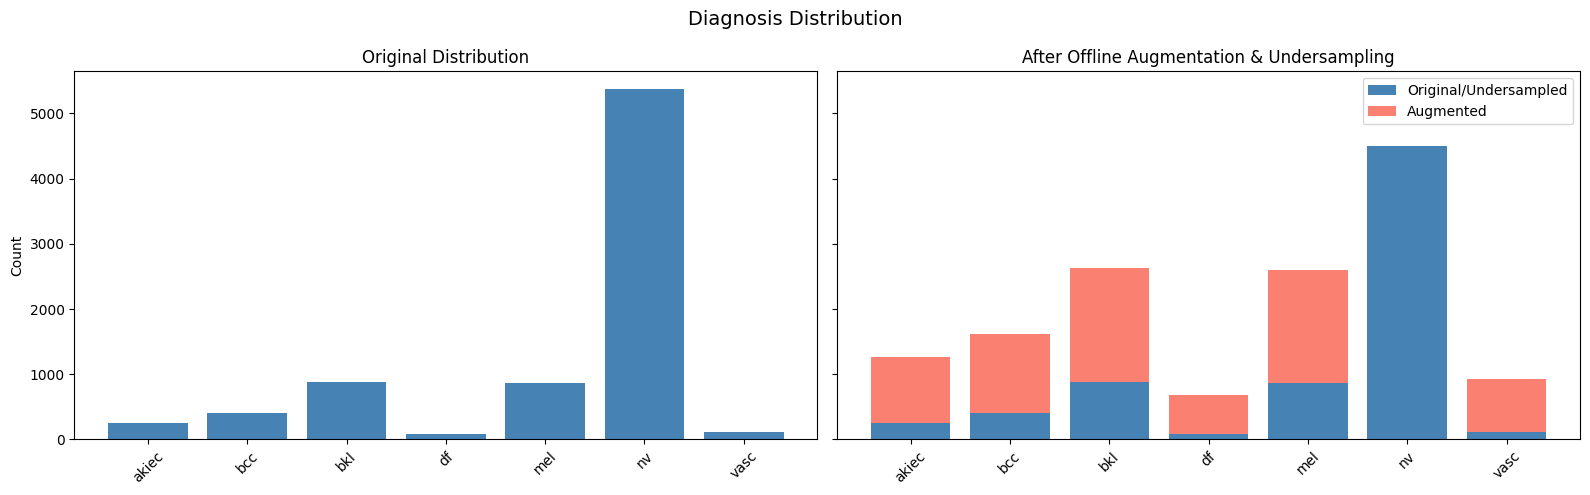

In [24]:
labels = sorted(aug_train_df["dx"].unique())
 
# Get original counts (unmodified)
original_counts = [len(train_df[train_df["dx"] == l]) for l in labels]
 
# Get final counts from augmented dataframe
final_counts = [len(aug_train_df[aug_train_df["dx"] == l]) for l in labels]
 
# For right chart: separate undersampled/original from augmented
undersampled_or_original = []
augmented_only = []
for i, label in enumerate(labels):
    if label == 'nv':
        # nv was undersampled to 4500
        undersampled_or_original.append(4500)
        augmented_only.append(final_counts[i] - 4500)
    else:
        # Other classes: original count + augmentation
        undersampled_or_original.append(original_counts[i])
        augmented_only.append(final_counts[i] - original_counts[i])
 
x = np.arange(len(labels))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
 
# ── Left: Original Distribution
axes[0].bar(x, original_counts, color="steelblue")
axes[0].set_title("Original Distribution")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45)
axes[0].set_ylabel("Count")
 
# ── Right: After Augmentation & Undersampling (stacked)
axes[1].bar(x, undersampled_or_original, color="steelblue", label="Original/Undersampled")
axes[1].bar(x, augmented_only, bottom=undersampled_or_original, color="salmon", label="Augmented")
axes[1].set_title("After Offline Augmentation & Undersampling")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45)
axes[1].legend()
 
plt.suptitle("Diagnosis Distribution", fontsize=14)
plt.tight_layout()
plt.show()

## Validating the augmentation pipeline with a simple model

In [25]:
aug_train_df.sample(5)

,image_id,dataset,lesion_id,image_path,dx,dx_encoded
2796,ISIC_0026833,original,HAM_0006070,./data\HAM10000_cleaned\train\ISIC_0026833_cle...,nv,5
2183,ISIC_0030623,original,HAM_0000871,./data\HAM10000_cleaned\train\ISIC_0030623_cle...,mel,4
10347,AUG_bkl_b5042fe1,augmented,AUG_LESION_bkl_8cc7f8af,./data\HAM10000_augmented\AUG_bkl_b5042fe1.jpg,bkl,2
2431,ISIC_0029610,original,HAM_0005459,./data\HAM10000_cleaned\train\ISIC_0029610_cle...,akiec,0
10086,AUG_bkl_ad60f5a3,augmented,AUG_LESION_bkl_50597541,./data\HAM10000_augmented\AUG_bkl_ad60f5a3.jpg,bkl,2


In [26]:
# Class weights
classes = np.array(sorted(aug_train_df["dx"].unique()))

class_weights = compute_class_weight(class_weight="balanced",classes=classes,y=aug_train_df["dx"])
class_weights_dict = {i: w for i, w in enumerate(class_weights)}

In [27]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # VERIFICAR PARA QUE É QUE ISTO SERVE
N_CLASSES  = len(label2idx) # VERIFICAR PARA QUE É QUE ISTO SERVE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

In [ ]:
def make_dataset(df, shuffle=False, repeat=False):
    paths = df["image_path"].values
    labels = df["dx_encoded"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda x, y: load_image(x, y), num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    
    if repeat:
        ds = ds.repeat()  

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

In [29]:
train_ds = make_dataset(aug_train_df, shuffle=True, repeat=True)  
val_ds   = make_dataset(val_df)                               
test_ds  = make_dataset(test_df)

In [ ]:
model_baseline = keras.Sequential([
    keras.layers.Conv2D(8, kernel_size=6, activation="relu", input_shape=(224, 224, 3)),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(N_CLASSES)
])

model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

c:\Users\tomas\anaconda3\envs\clean_ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
epochs = 10
spe = 100

history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    steps_per_epoch=spe,
    class_weight=class_weights_dict
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 161ms/step - accuracy: 0.2438 - loss: 1.9237 - val_accuracy: 0.1167 - val_loss: 1.9238
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.2225 - loss: 1.9619 - val_accuracy: 0.4484 - val_loss: 1.9023
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.3166 - loss: 1.9438 - val_accuracy: 0.6027 - val_loss: 1.8023
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.2856 - loss: 1.9062 - val_accuracy: 0.2893 - val_loss: 1.9447
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.2678 - loss: 1.9276 - val_accuracy: 0.4291 - val_loss: 1.8057
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.2909 - loss: 1.8890 - val_accuracy: 0.4253 - val_loss: 1.7227
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.2894 - loss: 1.9128 - val_accuracy: 0.1745 - val_loss: 2.1366
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.2844 - loss: 1.8876 -

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 161ms/step - accuracy: 0.2438 - loss: 1.9237 - val_accuracy: 0.1167 - val_loss: 1.9238
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.2225 - loss: 1.9619 - val_accuracy: 0.4484 - val_loss: 1.9023
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.3166 - loss: 1.9438 - val_accuracy: 0.6027 - val_loss: 1.8023
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.2856 - loss: 1.9062 - val_accuracy: 0.2893 - val_loss: 1.9447
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.2678 - loss: 1.9276 - val_accuracy: 0.4291 - val_loss: 1.8057
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.2909 - loss: 1.8890 - val_accuracy: 0.4253 - val_loss: 1.7227
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.2894 - loss: 1.9128 - val_accuracy: 0.1745 - val_loss: 2.1366
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.2844 - loss: 1.8876 - val_accuracy: 0.4185 - val_loss: 1.6894
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.3013 - loss: 1.8557 - val_accuracy: 0.4243 - val_loss: 1.6799
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.2666 - loss: 1.9082 - val_accuracy: 0.4118 - val_loss: 1.8139